# Einführung

# GDELT-Medienanalyse: Top-5 deutsche vs. Top-5 chinesische Automarken

Dieses Notebook untersucht die englischsprachige Medienberichterstattung 2021-2025 über die
fünf umsatzstärksten deutschen und fünf umsatzstärksten chinesischen Automarken (real aus den
KBA-Neuzulassungsdaten ermittelt, siehe `car_interest_nlp.analysis.top_brands.get_top_brands`),
auf Basis der öffentlichen GDELT DOC 2.0 API (`api.gdeltproject.org`).

**Alle Logik liegt in `src/car_interest_nlp/` -- dieses Notebook ruft ausschließlich bereits
implementierte Funktionen auf.** Die Zeitlimits für jede lang laufende Phase (Abruf, Volltext-
Scraping, NER-Training) werden hier als einfache Variablen gesetzt und an die jeweilige Funktion
übergeben (Standard: GDELT-Abruf 480 Minuten, weitere Phasen 15-200 Minuten).

## Einordnung und reale Einschränkungen

- **Kein synthetischer Fallback.** Jede Phase arbeitet mit echten, zwischengespeicherten Daten
  und meldet ihren tatsächlichen Abdeckungsgrad, statt fehlende Daten zu erfinden.
- **`timelinevol` und `artlist` sind vollständig getrennte Phasen, jede mit eigenem Abruf und
  eigenen Ergebnissen/Grafiken direkt im Anschluss.** `timelinevol` (schnell, ~10 Anfragen)
  kommt zuerst und liefert seine Medienaufmerksamkeits-Grafik, bevor der deutlich langsamere
  `artlist`-Abruf überhaupt beginnt.
- **Die GDELT-Suchanfrage ist für jede Marke nur die exakte, gequotete Phrase `"<Marke> car"`**
  (z. B. `"MG car"`), ohne weiteren Kontextbegriff. Grund für die Quotierung: zwei reale, direkt
  bestätigte GDELT-Fehler bei kurzen Markennamen -- "The specified phrase is too short" bei
  gequoteten Phrasen unter 4 Zeichen, und "Your search contained a keyword that was too short"
  auch bei ungequoteten bloßen Tokens (z. B. "MG", 2 Zeichen). Eine längen-abhängige Quotierung
  (nur quotieren, wenn lang genug) vermeidet daher keinen der beiden Fehler zuverlässig -- die
  Marke wird stattdessen nie mehr als eigenständiges kurzes Token gesendet, sondern immer als
  Teil der längeren, gequoteten Phrase "<Marke> car". Ein zusätzliches Kontextwort
  "german"/"chinese" wurde ausprobiert und wieder entfernt, nachdem ein direkter Live-Vergleich
  zeigte, dass es echte Treffer drastisch ausdünnt: für `"Volkswagen car"` sanken die Treffer
  mit "german" auf nur ~13 % der Tage im Zeitraum 2021-2025; ganz ohne Kontextwort lag derselbe
  Vergleich bei **54 % der Tage**, mit Werten bis zu zwei Größenordnungen höher (Maximalwert
  `0.0667` statt vereinzelter Ausreißer um `0.0004`).
- **`timelinevol`: eine einzige Anfrage je Marke über den gesamten Fünf-Jahres-Zeitraum**
  (10 Marken = 10 Anfragen) -- direkt bestätigt, dass dieser reale, ungedeckelte GDELT-Modus
  auch über ein volles Fünf-Jahres-Fenster echte Tagesdaten liefert (dieselben kleinen realen
  Datenlücken wie bei jahresweisem Abruf, keine fensterbreiten-spezifische Kürzung). Schlägt
  die Fünf-Jahres-Anfrage für eine Marke fehl, greift automatisch ein **Fallback auf fünf
  einzelne Ein-Jahres-Anfragen** für genau diese Marke (`year_windows`, separat bestätigt).
  `artlist` bleibt pro Anfrage auf `maxrecords=250` begrenzt -- echte gecachte Monats-Chunks
  für Volkswagen/Mercedes-Benz liefern bereits durchgehend genau 250/250 Artikel, ein
  breiteres Fenster würde also echte Artikel verlieren -- daher weiterhin monatlich gechunkt,
  round-robin über die abgefragten Marken hinweg statt Marke für Marke -- **direkt
  bestätigt**: Marke-für-Marke-Reihenfolge ließ nach 6 Stunden echten Abrufs 8 von 10 Marken
  bei null echter Abdeckung. Dieses Notebook beschränkt den `artlist`-Abruf inzwischen bewusst
  auf `GDELT_ARTLIST_BRANDS` (Volkswagen, BYD -- 2 × 60 statt 10 × 60 Monats-Anfragen), da ein
  voller Lauf über alle zehn Marken zu lange dauerte und die geografische Dominanzkarte weiter
  unten ohnehin nur diese beiden Marken braucht; `ensure_gdelt_artlist_dataset()` unterstützt
  weiterhin die volle Top-5+5-Auswahl (`brands=None`, der Standard), z. B. über
  `scripts/download_gdelt_news.py`.
- **GDELT drosselt/blockiert die Schnittstelle aggressiv** (eigene Vorgabe: "eine Anfrage alle 5
  Sekunden"; in der Entwicklungsumgebung dieses Projekts kam es trotz deutlich längerer Pausen
  wiederholt zu HTTP 429). Bei HTTP 429 wird derselbe Request erneut versucht: ein echter
  `Retry-After`-Header wird befolgt, sonst ein zufällig gestreutes exponentielles Backoff
  (1->60-120s, 2->120-240s, 3-14->150-300s, flach) mit einer harten Obergrenze von 5 Minuten je
  Wartezeit -- daher der großzügige Zeitbudget-Standardwert (bis zu 15 Versuche je Anfrage,
  im ungünstigsten Fall ca. 66 Minuten für einen einzigen hartnäckigen Chunk).
- **Live-/Cache-Modus:** `GDELT_FETCH_MODE` (unten) steuert beide GDELT-Abrufe. `"live"` ruft
  tatsächlich fehlende Daten ab; `"cached"` sendet **keine einzige Anfrage** und meldet nur
  den aktuellen, bereits zwischengespeicherten Stand -- praktisch, um dieses Notebook nach
  Abschluss der Datensammlung beliebig oft neu auszuführen (z. B. für die Grafiken), ohne
  weiter GDELTs Ratenbegrenzung zu strapazieren.
- **`mode=artlist` liefert nur Artikel-Metadaten und Titel, keinen Volltext.** Das optionale
  Volltext-Scraping (`fetch_article_texts`) holt echten Artikeltext direkt von den
  Original-Domains -- unter Beachtung von robots.txt und mit Domain-eigenem Rate-Limit, aber
  bestenfalls funktionierend (Paywalls/Blocks/JS-Rendering führen zu erwarteten, protokollierten
  Fehlschlägen, nicht zu Abbrüchen). Nicht gescrapte Artikel fallen auf den echten Titel als Text
  zurück, statt verworfen zu werden.
- **Die geografische Dominanzkarte (Volkswagen vs. BYD)** nutzt GDELTs reales `sourcecountry`-
  Feld aus den bereits gecachten `artlist`-Chunks -- keine zusätzliche GDELT-Anfrage. Siehe das
  entsprechende Kapitel weiter unten für die genaue Definition von `dominance_score`.
- **Die Wordcloud-/NER-Kapitel arbeiten mit dem, was bereits abgerufen/gescraped wurde** -- bei
  geringer Abdeckung sind die Ergebnisse entsprechend vorläufig; dies wird bei jedem Schritt
  geloggt.

In [ ]:
from pathlib import Path

from IPython.display import Image, display

from car_interest_nlp.analysis.media_attention import build_attention_over_time, summarize_attention_by_year
from car_interest_nlp.analysis.media_geography import build_country_dominance
from car_interest_nlp.analysis.top_brands import get_top_brands
from car_interest_nlp.config import load_project_config, resolve_project_path
from car_interest_nlp.data.article_text import fetch_article_texts
from car_interest_nlp.data.errors import SourceUnavailableError
from car_interest_nlp.data.gdelt_dataset_builder import (
    build_gdelt_analysis_dataset,
    collect_article_urls,
    ensure_gdelt_artlist_dataset,
    ensure_gdelt_timelinevol_dataset,
)
from car_interest_nlp.nlp.corpus import load_gdelt_corpus
from car_interest_nlp.nlp.ner.correction import load_corrected_annotations
from car_interest_nlp.nlp.ner.evaluate import evaluate_ner_model
from car_interest_nlp.nlp.ner.pipeline import extract_entities
from car_interest_nlp.nlp.ner.seed import export_seed_for_correction, generate_seed_annotations
from car_interest_nlp.nlp.ner.train import train_ner_model
from car_interest_nlp.nlp.wordclouds import generate_all_word_clouds
from car_interest_nlp.paths import ARTIFACTS_DIR
from car_interest_nlp.progress import TimeBudget
from car_interest_nlp.visualization.maps import plot_media_dominance_choropleth
from car_interest_nlp.visualization.trends import (
    plot_gdelt_article_count_trend,
    plot_gdelt_attention_trend,
    plot_gdelt_brand_attention_trend,
)

config = load_project_config()

# "live" fetches whatever real GDELT data is still missing; "cached" never sends a single
# request and only works with whatever is already on disk -- switch to "cached" once data
# collection is done, so re-running this notebook (e.g. to redo the graphs) never spends any
# more of GDELT's rate-limit tolerance. Still "live" for now.
GDELT_FETCH_MODE = "live"

# Restricts the (much slower) artlist fetch below to just these two brands instead of the
# full top-5+5 -- same build_query() criteria either way (see brand_queries()'s docstring),
# just fewer brands queried (2 x 60 months = 120 requests instead of 10 x 60 = 600), so a live
# run actually finishes in reasonable time. Chosen because the geographic dominance maps
# further below need real per-country artlist coverage specifically for Volkswagen vs. BYD.
# Already-cached chunks for these two brands from earlier full-10-brand runs are unaffected
# and still count as cached -- this only changes which brands get *newly* fetched.
GDELT_ARTLIST_BRANDS = ["Volkswagen", "BYD"]

# Matches GDELT_DEFAULT_MAX_ATTEMPTS (15, gdelt.py) explicitly rather than relying on the
# default silently -- kept as its own variable so a future change to the code-level default
# doesn't silently change this notebook's behavior. Each retry waits a jittered exponential
# backoff starting at 60s, hard-capped at 5 minutes per wait (see gdelt.py's
# `_jittered_backoff_seconds`) -- persistent real rate limiting has needed more than 6 attempts
# to get a response for some brands; a re-run only re-attempts brands that are still missing
# (already-cached ones are always skipped first), so raising this is safe to do between runs.
GDELT_MAX_ATTEMPTS = 15

# Time limits for every long-running phase in this notebook -- change these here, not inside
# the .py files, to control how long a given run of this notebook spends on each phase before
# stopping gracefully and leaving the rest for the next run (every phase caches per-item, so
# nothing is repeated). GDELT's real rate-limit tolerance is far stricter in practice than its
# documented "one request per 5 seconds", and the retry logic now waits out real 429s with a
# Retry-After-aware jittered backoff instead of giving up quickly, hence the generous 360-minute
# default for that phase specifically. This same budget is used for both the timelinevol and
# artlist fetch phases below, since each is called separately.
GDELT_FETCH_TIME_LIMIT_MINUTES = 480.0
ARTICLE_SCRAPING_TIME_LIMIT_MINUTES = 200.0
NER_TRAINING_TIME_LIMIT_MINUTES = 100.0

# Full-text scraping (beyond GDELT's own title/metadata) touches arbitrary third-party news
# domains -- opt-in per run, not automatic; see the Einführung above and README's "GDELT
# news analysis" section for the robots.txt/rate-limiting/legal caveats this carries.
ENABLE_ARTICLE_SCRAPING = True

# Every relative path literal used below (scraped-article storage, NER seed/model files) is
# resolved via resolve_project_path() against the project root, not this kernel's own cwd --
# a Jupyter kernel's cwd defaults to the notebook's own folder (notebooks/), so a bare
# relative path here would otherwise silently write under notebooks/data/... instead of the
# project's real data/ directory (confirmed directly: this happened to real scraped article
# files before this fix).

# Top-5 Marken je Gruppe

`get_top_brands()` ermittelt die fünf umsatzstärksten deutschen und chinesischen Marken real
aus den kumulierten KBA-Neuzulassungszahlen 2021-2025 (`data/interim/kba/kba_annual_brand_totals.csv`)
-- keine feste, geratene Liste. Diese zehn Marken werden in allen folgenden Kapiteln abgefragt.


In [2]:
top_brands = get_top_brands(5)
top_brands

2026-07-16 03:13:35,099 | INFO | Using tidied KBA file at D:\Master\Projects\NLP_Projekt\Car_Trends\data\interim\kba\kba_annual_brand_totals.csv
2026-07-16 03:13:35,122 | INFO | Built KBA registration series with 86 rows (mode=cached)


{'german': ['Volkswagen', 'Mercedes-Benz', 'BMW', 'Audi', 'Opel'],
 'chinese': ['MG', 'BYD', 'Polestar', 'Great Wall', 'Lynk & Co']}

# GDELT timelinevol-Abruf (real, wiederaufnehmbar)

`ensure_gdelt_timelinevol_dataset()` fragt GDELTs Aggregat-Modus `timelinevol` ab -- **eine
einzige Anfrage je Marke über den gesamten Zeitraum 2021-2025** (10 Marken = 10 Anfragen,
direkt bestätigt: dieser reale, ungedeckelte GDELT-Modus liefert auch über ein volles
Fünf-Jahres-Fenster echte Tagesdaten, mit denselben kleinen realen Datenlücken, die auch in
jahresweise gechunkten Abrufen auftreten -- keine fensterbreiten-spezifische Kürzung).
Schlägt die Fünf-Jahres-Anfrage für eine Marke nach allen Wiederholungsversuchen fehl, greift
automatisch ein Fallback auf fünf einzelne Ein-Jahres-Anfragen für genau diese Marke
(`year_windows`, die bereits separat bestätigte Granularität).

`fetch_mode=GDELT_FETCH_MODE` steuert Live-/Cache-Modus (siehe Einführung oben): `"live"`
ruft tatsächlich fehlende Daten ab, `"cached"` meldet nur den aktuellen Stand, ohne
irgendeine Anfrage zu senden. `max_attempts=GDELT_MAX_ATTEMPTS` überschreibt die Standard-
Anzahl an Wiederholungsversuchen je Anfrage (Standard 15, mit einem auf 60s startenden,
bei 5 Minuten je Wartezeit hart gedeckelten exponentiellen Backoff) -- bereits gecachte
Marken werden immer zuerst übersprungen, ein erneuter Lauf setzt also automatisch genau dort
fort, wo der vorherige aufgehört hat, und versucht nur die noch fehlenden Marken erneut.
Dieser Abruf stoppt nach `GDELT_FETCH_TIME_LIMIT_MINUTES` und muss im Live-Modus für
vollständige Abdeckung ggf. mehrfach erneut ausgeführt werden. Die Ergebnisse/Grafiken dieser
Phase werden direkt im Anschluss gezeigt, bevor es mit dem viel langsameren `artlist`-Abruf
weitergeht.

In [ ]:
timelinevol_fetch_summary = ensure_gdelt_timelinevol_dataset(
    fetch_mode=GDELT_FETCH_MODE,
    max_attempts=GDELT_MAX_ATTEMPTS,
    time_budget=TimeBudget(minutes=GDELT_FETCH_TIME_LIMIT_MINUTES),
)
timelinevol_fetch_summary

# Medienaufmerksamkeit über die Zeit

Basiert ausschließlich auf GDELTs eigenem Aggregat-Modus (`timelinevol`) -- unabhängig vom
Artikel-/Scraping-Fortschritt weiter unten. `timelinevol` liefert echte **tägliche**
Datenpunkte (Anteil an der weltweiten, von GDELT überwachten Berichterstattung an diesem
Tag); GDELT bietet keinen dokumentierten Parameter, um stattdessen direkt vorab auf
Jahresebene aggregierte Werte abzufragen. `summarize_attention_by_year()` bildet daher offline,
ganz ohne zusätzliche Anfragen, aus den bereits abgerufenen Tageswerten je Marke und Jahr den
**Mittelwert** (nicht die Summe -- tägliche Prozentwerte aufzusummieren ergäbe keinen
sinnvollen "Jahresanteil" und könnte trivial über 100 % steigen; der Mittelwert beantwortet
dagegen die reale Frage "wie hoch war der Berichterstattungsanteil an einem typischen Tag
dieses Jahres").

In [ ]:
attention_over_time = build_attention_over_time()
attention_by_year = summarize_attention_by_year(attention_over_time)

ARTIFACTS_DIR.joinpath("tables").mkdir(parents=True, exist_ok=True)
attention_over_time.to_csv(
    ARTIFACTS_DIR / "tables" / "gdelt_attention_over_time.csv", index=False, encoding="utf-8"
)
attention_by_year.to_csv(
    ARTIFACTS_DIR / "tables" / "gdelt_attention_by_year.csv", index=False, encoding="utf-8"
)

print(f"attention-over-time rows (daily): {len(attention_over_time)}")
print(f"attention-by-year rows (yearly mean): {len(attention_by_year)}")
display(attention_by_year)

attention_trend_path = plot_gdelt_attention_trend(
    attention_by_year, ARTIFACTS_DIR / "figures" / "gdelt" / "gdelt_attention_trend.png"
)
display(Image(filename=str(attention_trend_path)))

## Direktvergleich: Volkswagen vs. BYD

Zusätzlich zum Gruppenvergleich oben (alle deutschen vs. alle chinesischen Marken summiert)
hier derselbe Zwei-Marken-Direktvergleich wie im Google-Trends-Kapitel des anderen Notebooks
(`consumer_interest_analysis.ipynb`), diesmal aber für reale Medienberichterstattung statt
Sucheinteresse. `plot_gdelt_brand_attention_trend()` filtert direkt auf die beiden genannten
Marken, ohne Gruppen-Aggregation.

In [ ]:
vw_byd_trend_path = plot_gdelt_brand_attention_trend(
    attention_by_year, ARTIFACTS_DIR / "figures" / "gdelt" / "gdelt_vw_byd_trend.png"
)
display(Image(filename=str(vw_byd_trend_path)))

# GDELT artlist-Abruf (real, wiederaufnehmbar)

`ensure_gdelt_artlist_dataset()` fragt GDELTs Artikel-Metadaten-Modus `artlist` ab -- monatlich
gechunkt, 2021-2025, round-robin (siehe Einführung oben) -- und speichert jeden Chunk einzeln
unter `data/raw/gdelt/`. **Beschränkt auf `brands=GDELT_ARTLIST_BRANDS` (Volkswagen, BYD)**,
nicht die volle Top-5+5-Auswahl: dieselben Abfrage-Kriterien wie zuvor (`build_query()`), nur
2 x 60 statt 10 x 60 Monats-Anfragen -- ein voller Lauf über alle zehn Marken dauerte zu lange;
diese beiden Marken werden für die geografische Dominanzkarte weiter unten benötigt. Bereits
zwischengespeicherte Chunks anderer Marken aus früheren Läufen bleiben unangetastet erhalten,
werden hier aber nicht weiter vervollständigt. Dies ist die deutlich langsamere der beiden
GDELT-Phasen, daher erst jetzt gestartet, nachdem die schnelle `timelinevol`-Phase bereits echte
Ergebnisse/Grafiken geliefert hat. `fetch_mode=GDELT_FETCH_MODE` steuert wie oben Live-/
Cache-Modus. Bereits vorhandene Chunks werden nie erneut abgefragt -- dieser Aufruf stoppt nach
`GDELT_FETCH_TIME_LIMIT_MINUTES` und muss im Live-Modus für vollständige Abdeckung mehrfach
erneut ausgeführt werden.

In [ ]:
artlist_fetch_summary = ensure_gdelt_artlist_dataset(
    brands=GDELT_ARTLIST_BRANDS,
    fetch_mode=GDELT_FETCH_MODE,
    max_attempts=GDELT_MAX_ATTEMPTS,
    time_budget=TimeBudget(minutes=GDELT_FETCH_TIME_LIMIT_MINUTES),
)
artlist_fetch_summary

# Artikel-Zeitreihe je Marke

`build_gdelt_analysis_dataset()` fasst die real gecachten `artlist`-Chunks zu einer jährlichen
Artikelanzahl je Marke zusammen (analog zu den KBA-/Schweiz-/Trends-Kapiteln) und meldet dabei
seinen tatsächlichen Abdeckungsgrad. Da keine "Sonstige"-Kategorie existiert (jede abgefragte
Marke wurde bewusst gewählt, nicht aus einem Rohbericht geparst), löst diese Funktion
`SourceUnavailableError` aus, solange noch kein einziger `artlist`-Chunk zwischengespeichert ist
-- hier abgefangen, damit die folgenden, unabhängigen Kapitel trotzdem ausgeführt werden.

**Das ist die reale Artikelanzahl je Marke und Jahr** (nicht `timelinevol`s normalisierter
Intensitäts-Prozentwert -- die beiden sind nicht dasselbe, siehe Einführung oben).
`plot_gdelt_article_count_trend()` stellt diese Zeitreihe als Liniendiagramm dar, eine Linie
je Marke, analog zum Google-Trends-Kapitel im anderen Notebook.

In [ ]:
try:
    gdelt_article_series = build_gdelt_analysis_dataset()
    display(gdelt_article_series.tail(10))
    article_count_trend_path = plot_gdelt_article_count_trend(
        gdelt_article_series, ARTIFACTS_DIR / "figures" / "gdelt" / "gdelt_article_count_trend.png"
    )
    display(Image(filename=str(article_count_trend_path)))
except SourceUnavailableError as exc:
    gdelt_article_series = None
    print(f"Noch keine artlist-Chunks zwischengespeichert: {exc.reason}")

# Geografische Mediendominanz: Volkswagen vs. BYD

Nutzt GDELTs reales `sourcecountry`-Feld (das Land des jeweiligen Nachrichtenportals, direkt
aus den bereits gecachten `artlist`-Chunks von oben) -- **keine zusätzliche GDELT-Anfrage**.
`build_country_dominance()` zählt je Land und Jahr die real erfassten Artikel über Volkswagen
und über BYD und bildet daraus einen `dominance_score` von `-1` (jeder Artikel dieses Landes
nannte nur BYD) bis `+1` (nur Volkswagen); Länder mit weniger als zwei kombinierten Artikeln
werden verworfen, statt ein verrauschtes `+-1` aus einem einzigen Artikel zu zeigen. Dies misst,
über welche Marke die englischsprachigen Medien eines Landes mehr berichteten -- keine
Marktanteile oder Popularität in der Bevölkerung dieses Landes. Zwei Weltkarten, 2021 und 2025,
zeigen die reale Verschiebung über den Berichtszeitraum; ein Land ohne echte Abdeckung für ein
Jahr bleibt auf der Karte einfach ungefärbt statt mit einem erfundenen Wert.

In [ ]:
country_dominance = build_country_dominance(brands=GDELT_ARTLIST_BRANDS)

ARTIFACTS_DIR.joinpath("tables").mkdir(parents=True, exist_ok=True)
country_dominance.to_csv(
    ARTIFACTS_DIR / "tables" / "gdelt_country_dominance.csv", index=False, encoding="utf-8"
)
print(f"country-dominance rows: {len(country_dominance)}")
display(country_dominance)

for dominance_year in (2021, 2025):
    dominance_map_path = plot_media_dominance_choropleth(
        country_dominance,
        dominance_year,
        ARTIFACTS_DIR / "figures" / "gdelt" / f"gdelt_media_dominance_{dominance_year}.png",
    )
    display(Image(filename=str(dominance_map_path)))

# Volltext-Scraping (optional, standardmäßig deaktiviert)

Holt echten Artikeltext direkt von den Original-Domains, robots.txt-konform und mit
Domain-eigenem Rate-Limit -- der riskanteste Teil dieses Projekts (Hunderte verschiedene
Nachrichten-Domains mit jeweils eigenen Regeln), daher bewusst nur bei `ENABLE_ARTICLE_SCRAPING
= True` aktiv. Fehlgeschlagene Abrufe (Paywall/Block/JS-Rendering) werden protokolliert und
übersprungen, nicht als Fehler behandelt.


In [ ]:
scraping_config = config["sources"].get("gdelt", {}).get("scraping", {})

if ENABLE_ARTICLE_SCRAPING:
    article_urls = collect_article_urls()
    scraping_summary = fetch_article_texts(
        article_urls,
        resolve_project_path(scraping_config.get("raw_directory", "data/raw/gdelt_articles")),
        user_agent=scraping_config.get("user_agent", "car-interest-nlp-research-bot/1.0"),
        per_domain_delay_seconds=float(scraping_config.get("per_domain_delay_seconds", 3.0)),
        respect_robots_txt=bool(scraping_config.get("respect_robots_txt", True)),
        time_budget=TimeBudget(minutes=ARTICLE_SCRAPING_TIME_LIMIT_MINUTES),
    )
    print(scraping_summary)
else:
    print("ENABLE_ARTICLE_SCRAPING is False -- skipping full-text scraping for this run.")

# Wordclouds

`load_gdelt_corpus()` lädt die real gecachten `artlist`-Artikel und hängt echten Volltext an,
wo bereits gescraped (sonst den echten Titel als Fallback). Sieben Kategorien, wie gefordert:
Deutsche/Chinesische Marken (Häufigkeit + TF-IDF), eine je Berichtsjahr, Technologie-bezogen und
Regulierung/Zölle -- Markennamen/Aliase (`configs/brands.yaml`), generische Quellen-Boilerplate
und generische Begriffe ("car"/"vehicle") sind überall ausgeschlossen
(`nlp.text_cleaning.clean_tokens`).


2026-07-15 22:35:31,792 | INFO | Using tidied KBA file at D:\Master\Projects\NLP_Projekt\Car_Trends\data\interim\kba\kba_annual_brand_totals.csv
2026-07-15 22:35:31,808 | INFO | Built KBA registration series with 86 rows (mode=cached)
2026-07-15 22:35:31,814 | INFO | Using tidied KBA file at D:\Master\Projects\NLP_Projekt\Car_Trends\data\interim\kba\kba_annual_brand_totals.csv
2026-07-15 22:35:31,827 | INFO | Built KBA registration series with 86 rows (mode=cached)
2026-07-15 22:35:31,878 | INFO | Loaded GDELT corpus from 15/600 expected (brand, month) article chunks
2026-07-15 22:35:34,449 | INFO | Skipping 'chinese' word cloud: No terms to render a word cloud for 'Chinesische Marken in den Medien (Häufigkeit)' -- corpus is empty.
2026-07-15 22:35:36,828 | INFO | Skipping 'chinese_tfidf' word cloud: No terms to render a word cloud for 'Chinesische Marken in den Medien (TF-IDF)' -- corpus is empty.


Erzeugte Wordclouds: ['german', 'german_tfidf', 'regulation', 'technology', 'year_2021', 'year_2022']


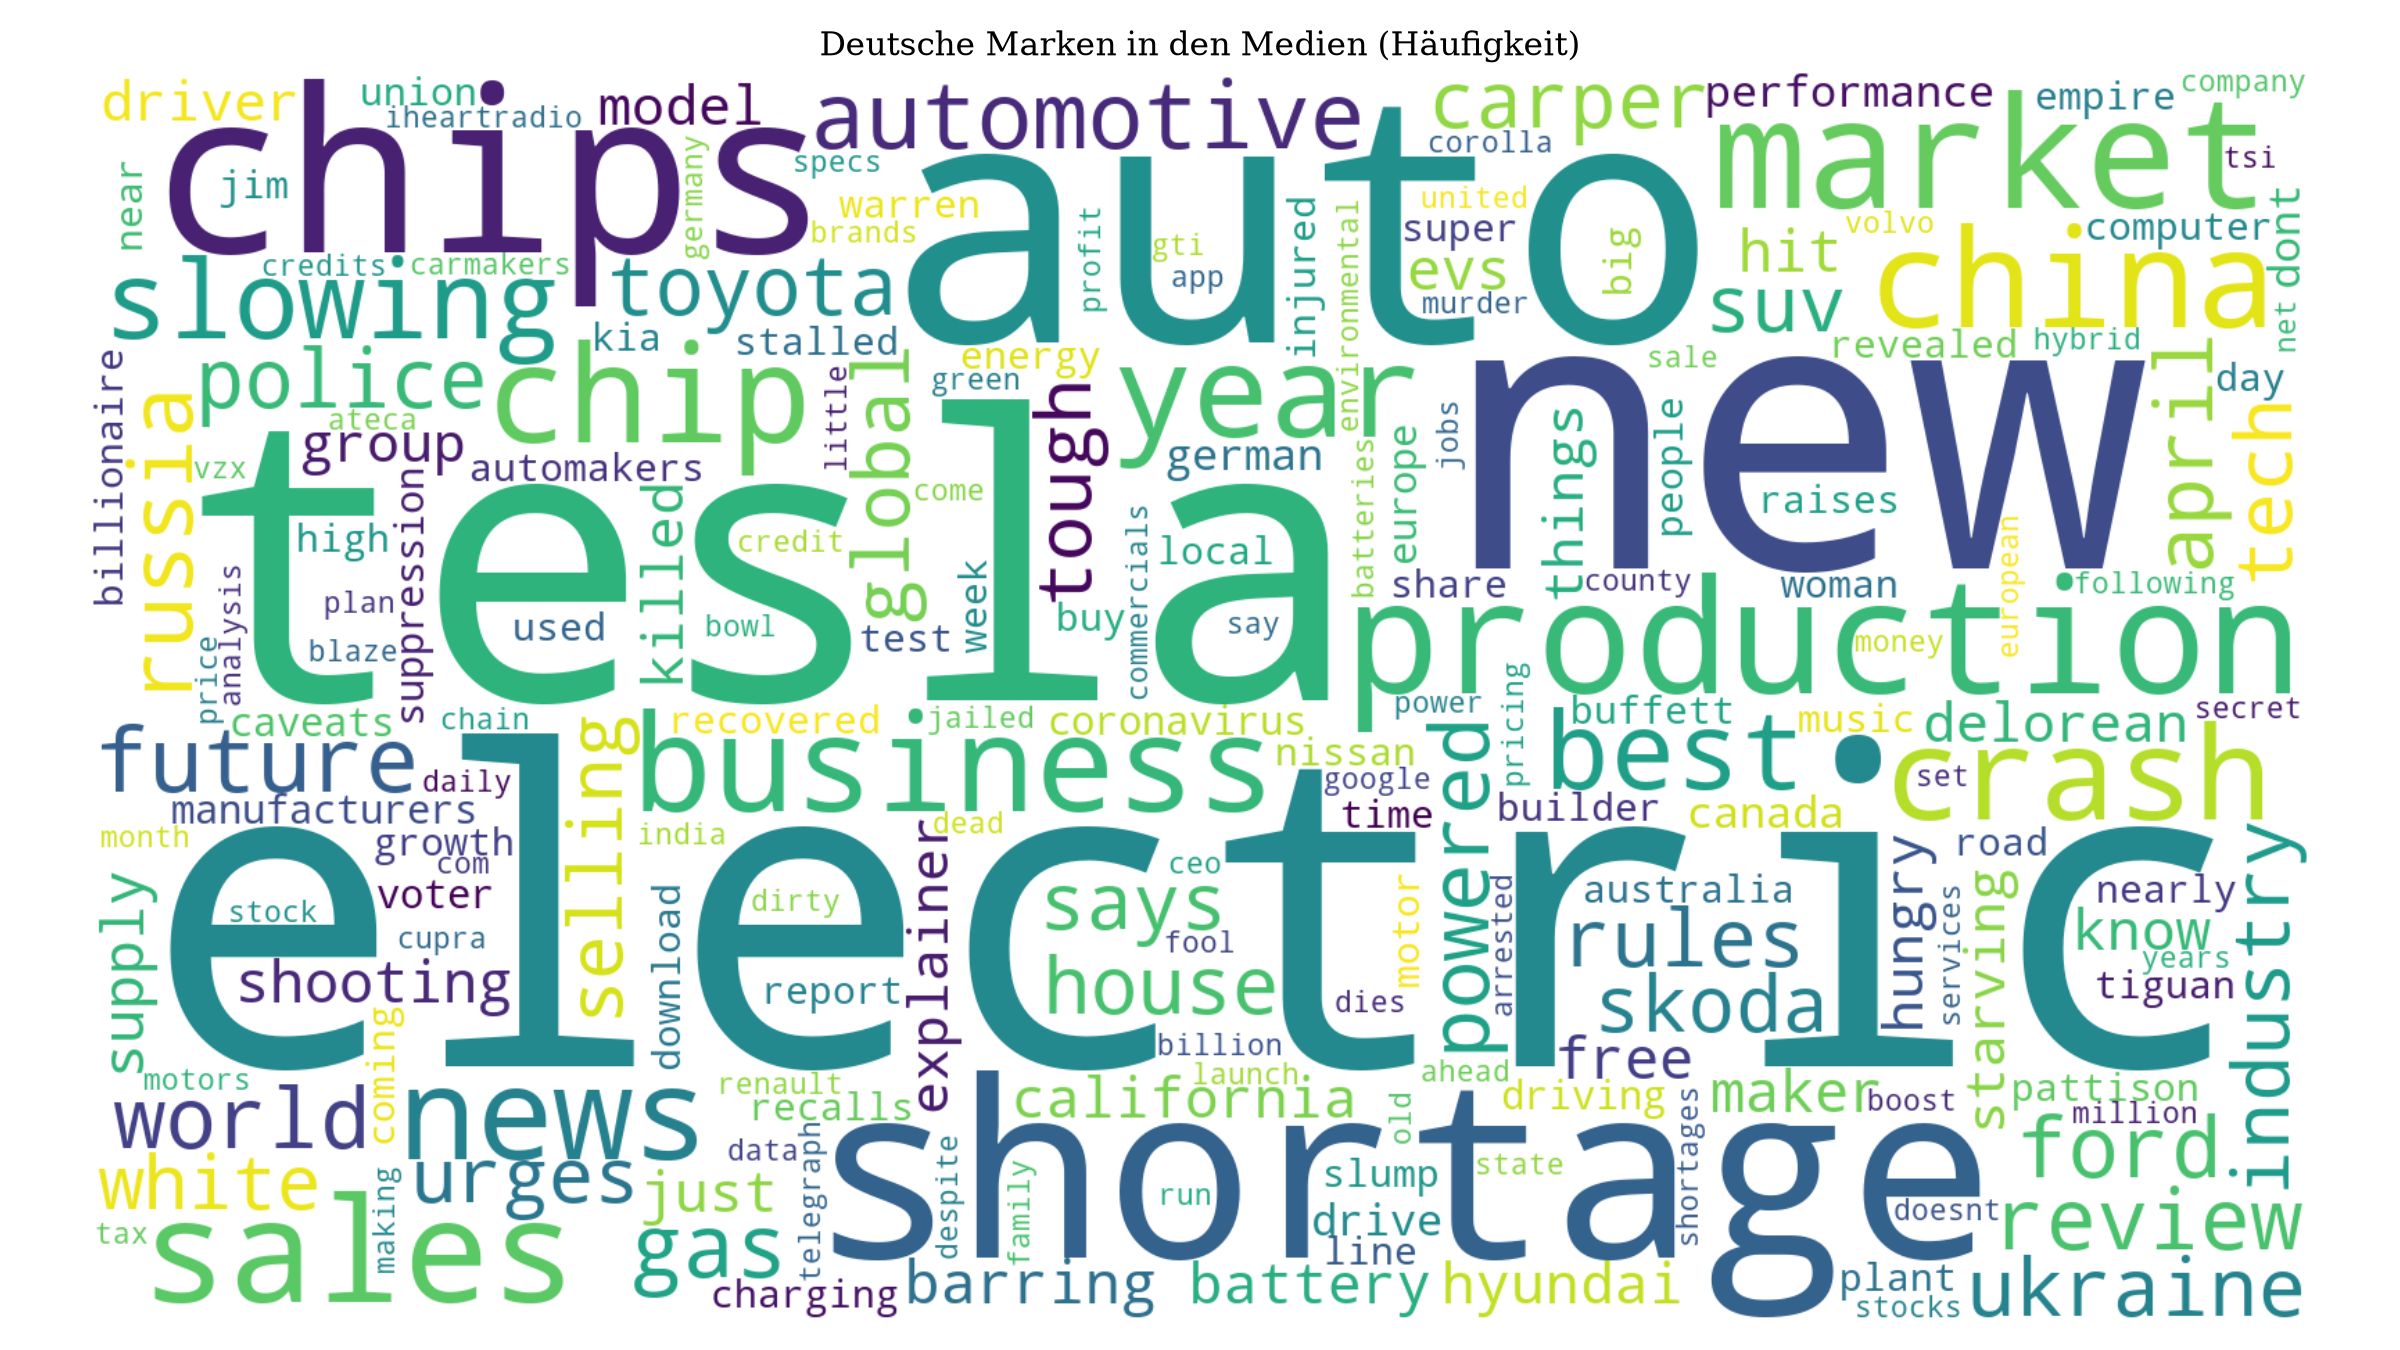

In [ ]:
gdelt_corpus = load_gdelt_corpus()
wordcloud_dir = ARTIFACTS_DIR / "figures" / "gdelt"

if gdelt_corpus.empty:
    print("Noch kein Artikel-Korpus verfügbar -- die Wordcloud-Zellen werden übersprungen.")
    wordcloud_paths = {}
else:
    wordcloud_paths = generate_all_word_clouds(gdelt_corpus, wordcloud_dir)
    print(f"Erzeugte Wordclouds: {sorted(wordcloud_paths)}")
    if "german" in wordcloud_paths:
        display(Image(filename=str(wordcloud_paths["german"])))
    if "chinese" in wordcloud_paths:
        display(Image(filename=str(wordcloud_paths["chinese"])))

# Automotive-NER, Stage A (regelbasiert, sofort einsatzbereit)

`extract_entities()` kombiniert eine echte vortrainierte spaCy-Pipeline (`en_core_web_sm`) mit
einem regelbasierten `EntityRuler`, dessen Muster direkt aus `configs/brands.yaml`
(CAR_BRAND) und `configs/ner_gazetteer.yaml` (CAR_MODEL/SUPPLIER/TECHNOLOGY/COMPONENT/FACTORY/
REGULATION) stammen -- LOCATION/PERSON/ORGANIZATION kommen weiterhin aus dem vortrainierten
Modell. Stage A benötigt kein Training und läuft unabhängig vom Artikel-Korpus-Fortschritt; hier
auf dem echten Korpus (falls vorhanden) oder andernfalls auf Beispielsätzen gezeigt.


In [ ]:
# Fallback-Beispielsätze, nur falls noch kein echter Artikel-Korpus vorliegt -- sobald
# GDELT-Artikel gecacht sind, verwendet diese Zelle deren echten Text/Titel.
_FALLBACK_EXAMPLE_SENTENCES = [
    "BYD announced a new LFP battery factory in Debrecen, Hungary, supplied in part by CATL.",
    "The EU tariff on Chinese EVs like the BYD Seal and MG4 has raised concerns at Volkswagen.",
    "BMW unveiled the new BMW X5 with an 800-volt architecture and Bosch-supplied ADAS technology.",
]

ner_sample_texts = (
    gdelt_corpus["text"].dropna().head(20).tolist()
    if not gdelt_corpus.empty
    else _FALLBACK_EXAMPLE_SENTENCES
)
stage_a_entities = extract_entities(ner_sample_texts)
stage_a_entities

,doc_index,text,label,start_char,end_char
0,0,15,CARDINAL,4,6
1,0,Best Super Bowl Commercials,EVENT,7,34
2,1,15,CARDINAL,4,6
3,1,Best Super Bowl Commercials,EVENT,7,34
4,2,Best Rock Super Bowl Commercials,ORG,0,32
5,3,Best Rock Super Bowl Commercials,ORG,0,32
6,4,Ford,ORG,0,4
7,4,Google,ORG,7,13
8,5,Best Rock Super Bowl Commercials,ORG,0,32
9,6,Best Rock Super Bowl Commercials,ORG,0,32


# Automotive-NER, Stage B (trainierbares Modell)

Drei Schritte, jeder eine reine Funktions-Aufrufkette:

1. **Seed-Annotationen** aus Stage A generieren (`generate_seed_annotations`) und für die
   manuelle Korrektur exportieren (`export_seed_for_correction`) -- Stage As regelbasierte
   Treffer sind präzise, seine vortrainierten Labels (PERSON/ORG/GPE/...) können aber falsch
   liegen; genau dafür ist die manuelle Korrektur da.
2. **Manuelle Korrektur** (außerhalb dieses Notebooks): die exportierte JSONL-Datei öffnen,
   `entities`-Einträge korrigieren, `"verified": true` je geprüfter Zeile setzen, speichern.
3. **Training + Evaluation** auf den korrigierten Annotationen (`train_ner_model`,
   `evaluate_ner_model`) -- startet von der echten vortrainierten Pipeline, nicht bei null
   (siehe Docstring von `train_ner_model`), mit Zeitlimit `NER_TRAINING_TIME_LIMIT_MINUTES`.

Ohne eine bereits manuell korrigierte Datei zeigt dieser Abschnitt nur Schritt 1 (Seed-Export);
Schritt 3 wird übersprungen, bis eine echte, geprüfte Annotationsdatei vorliegt.


In [ ]:
seed_annotations = generate_seed_annotations(ner_sample_texts)
seed_path = export_seed_for_correction(
    seed_annotations, resolve_project_path("data/interim/ner/seed_annotations.jsonl")
)
print(f"{len(seed_annotations)} Seed-Annotationen nach {seed_path} geschrieben.")
print(
    "Manuell korrigieren, 'verified': true je Zeile setzen, dann die nächste Zelle erneut ausführen."
)

CORRECTED_ANNOTATIONS_PATH = resolve_project_path("data/interim/ner/seed_annotations_corrected.jsonl")
if CORRECTED_ANNOTATIONS_PATH.is_file():
    corrected_records = load_corrected_annotations(CORRECTED_ANNOTATIONS_PATH)
else:
    corrected_records = []
    print(
        f"Noch keine korrigierte Annotationsdatei unter {CORRECTED_ANNOTATIONS_PATH} -- "
        "Training/Evaluation werden übersprungen."
    )

if corrected_records:
    ner_model, ner_dev_records = train_ner_model(
        corrected_records,
        output_dir=resolve_project_path("data/interim/ner/model"),
        time_budget=TimeBudget(minutes=NER_TRAINING_TIME_LIMIT_MINUTES),
    )
    export_seed_for_correction(
        ner_dev_records, resolve_project_path("data/interim/ner/model/dev_split.jsonl")
    )
    ner_scores = evaluate_ner_model(ner_model, ner_dev_records)
    print(ner_scores)

## Zusammenfassung

Dieses Kapitel misst öffentliche englischsprachige Medienberichterstattung (GDELT), nicht
Marktergebnisse oder Sucheinteresse -- die KBA-/Schweiz-/Google-Trends-Kapitel im anderen
Notebook (`consumer_interest_analysis.ipynb`) bleiben die Quellen dafür. Es gibt keinen
synthetischen Fallback: Jede Phase meldet ihren tatsächlichen Abdeckungsgrad und läuft mit
echten, zwischengespeicherten Daten weiter, statt fehlende Daten zu erfinden. Reale vollständige
Abdeckung (Artikel-Metadaten, optionales Volltext-Scraping, von Hand korrigierte
NER-Trainingsdaten) erfordert mehrere fortgesetzte Läufe dieses Notebooks bzw. der
`scripts/`-Einstiegspunkte -- `download_gdelt_news.py`, `fetch_article_texts.py`,
`build_media_attention_report.py`, `generate_news_wordclouds.py`, `build_ner_seed.py`,
`train_ner_model.py`, `evaluate_ner_model.py` bieten denselben Ablauf als reproduzierbare
Kommandozeilen-Einstiegspunkte.
